## 컬리 패션 카테고리 EDA

`kurly_crawler.py`로 수집한 컬리 패션 카테고리(165 패션의류 등) 상품·리뷰 데이터 EDA.
무신사 EDA(`analysis.ipynb`)와 같은 흐름이되, 컬리 데이터 특성에 맞춰 조정했다.

- **별점 없음** → 평점 분석 대신 리뷰수(누적 판매 프록시) 집중도 분석
- **리뷰 수 상한 표기(`999+`)** → 999로 치환하고 상한 도달 여부를 따로 보존
- **브랜드 필드 없음** → 상품명 `[브랜드]` 추출값이라 미표기 상품 존재

In [1]:
import json
import re
from collections import Counter
from glob import glob

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 차트 팔레트 — 시리즈는 파랑 단일 색, 긍/부정 비교만 파랑↔빨강 (극성 대비)
BLUE, RED = '#2a78d6', '#e34948'
INK, SECONDARY, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
SURFACE = '#fcfcfb'

# 설치된 한글 폰트를 골라 하나만 지정 (리스트로 주면 없는 폰트마다 경고가 나옴)
_available = {f.name for f in font_manager.fontManager.ttflist}
FONT = next((f for f in ('Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR')
             if f in _available), 'DejaVu Sans')

plt.rcParams.update({
    'font.family': FONT,
    'axes.unicode_minus': False,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': '#c3c2b7',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': False, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True,
    'text.color': INK, 'axes.labelcolor': SECONDARY,
    'xtick.color': MUTED, 'ytick.color': MUTED,
})

#### 데이터 로드 · 전처리

`CATEGORY`만 바꾸면 166·169 등 다른 카테고리도 같은 노트북으로 분석할 수 있다.

In [2]:
CATEGORY = '166'  # 165 패션의류 · 166 · 169 — 수집해 둔 카테고리 코드로 변경

# 같은 카테고리를 여러 날 수집해도 최신 파일을 집도록 glob 사용
with open(sorted(glob(f'data/kurly_products_{CATEGORY}_*.json'))[-1], encoding='utf-8') as f:
    prod = pd.DataFrame(json.load(f)).drop(columns=['_goods_no'])

rev_files = sorted(glob(f'data/kurly_reviews_{CATEGORY}_*.json'))
if rev_files:
    with open(rev_files[-1], encoding='utf-8') as f:
        rev = pd.DataFrame(json.load(f))
else:
    rev = pd.DataFrame()
    print('리뷰 파일이 없습니다 — 5장(리뷰 텍스트)은 리뷰 수집 후 실행하세요.')

CATEGORY_NAME = prod['Category'].iloc[0]
prod.shape, rev.shape

((96, 11), (296, 6))

In [3]:
# 문자열 필드를 숫자로 변환 (품절 등으로 가격이 빈 상품은 제외)
prod['가격'] = pd.to_numeric(prod['Price'].str.replace(',', ''), errors='coerce')
prod['정가'] = pd.to_numeric(prod['Original Price'].str.replace(',', ''), errors='coerce')
prod = prod.dropna(subset=['가격']).astype({'가격': int, '정가': int})
prod['할인율'] = pd.to_numeric(prod['Discount Rate'].str.rstrip('%'), errors='coerce').fillna(0).astype(int)

# 리뷰 수는 '999+'처럼 상한 표기가 있어 숫자로 바꾸고 상한 여부를 보존
prod['리뷰수상한'] = prod['Review Count'].str.endswith('+')
prod['리뷰수'] = prod['Review Count'].str.replace(',', '').str.rstrip('+').astype(int)

prod['브랜드'] = prod['Brand'].replace('', '(미표기)')

if len(rev):
    rev['날짜'] = pd.to_datetime(rev['Review Date'], errors='coerce')
    rev['본문길이'] = rev['Review Body'].str.len()

prod[['Rank', '브랜드', 'Product Name', '가격', '할인율', '리뷰수']].head()

,Rank,브랜드,Product Name,가격,할인율,리뷰수
0,1,솔트워터,[솔트워터] 오리지널 샌들 탄 TAN,93245,27,0
1,2,주말특가,[주말특가][벤시몽] 테니스 엘리/엘라스틱/라셋 스니커즈 3종 (택 1),59000,0,103
2,3,아치스,[아치스] 조리 토프,49900,0,60
3,4,베흐트,[베흐트] 하우트 스와로브스키 진주 귀걸이 3종 (택1),40880,44,313
4,5,아치스,[아치스] 조리 브라운,49900,0,20


#### 1. 가격대 분포

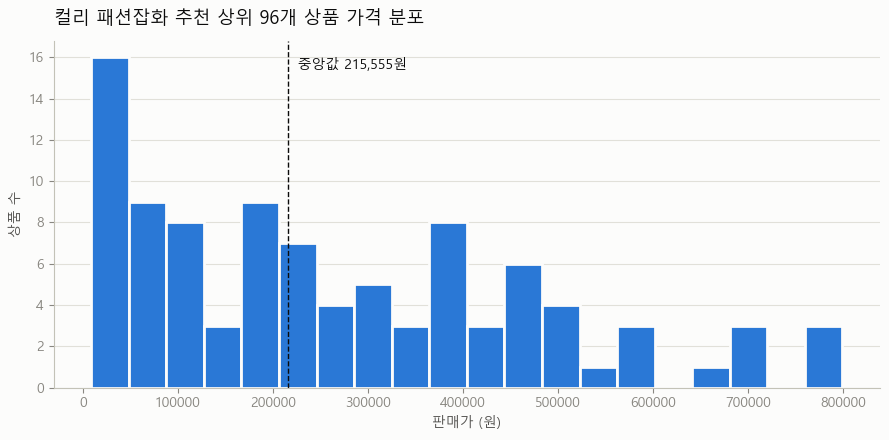

가격 범위 8,932~974,000원 / 중앙값 215,555원


In [4]:
cap = int(prod['가격'].quantile(0.99))  # 극단 고가 1%는 마지막 구간에 몰아넣어 가독성 확보
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(prod['가격'].clip(upper=cap), bins=20, color=BLUE, edgecolor=SURFACE, linewidth=2)
med = prod['가격'].median()
ax.axvline(med, color=INK, linewidth=1, linestyle='--')
ax.text(med, ax.get_ylim()[1] * 0.95, f'  중앙값 {med:,.0f}원', va='top', fontsize=10)
ax.set_xlabel('판매가 (원)')
ax.set_ylabel('상품 수')
ax.set_title(f'컬리 {CATEGORY_NAME} 추천 상위 {len(prod)}개 상품 가격 분포', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(f"가격 범위 {prod['가격'].min():,}~{prod['가격'].max():,}원 / 중앙값 {med:,.0f}원")

**고단가 잡화 — 중앙값 215,555원, 다른 리그의 가격대**

- 가격 범위 8,932~974,000원. 주얼리·슈즈·가방 등 고가 잡화가 상위를 채운다
- 같은 속옷·홈웨어 성격의 무신사 026(중앙값 34,405원)의 6배, 레저/홈웨어(169, 20,912원)의 10배 — 같은 컬리 안에서도 카테고리별 가격 리그가 완전히 다르다

#### 2. 할인 구조

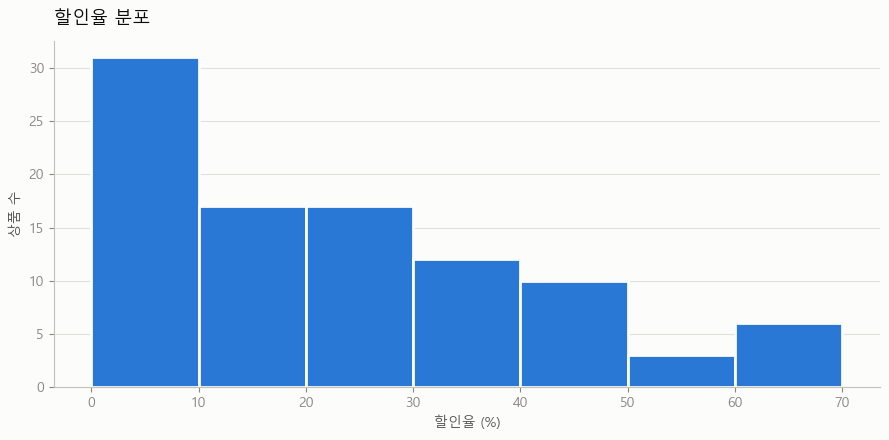

정가 판매(0%): 28개 / 96개
할인율 중앙값 20%, 최대 69%
25% 이상 할인 상품 비율: 44%


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(prod['할인율'], bins=range(0, prod['할인율'].max() + 11, 10), color=BLUE,
        edgecolor=SURFACE, linewidth=2)
ax.set_xlabel('할인율 (%)')
ax.set_ylabel('상품 수')
ax.set_title('할인율 분포', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

n = len(prod)
print(f"정가 판매(0%): {(prod['할인율'] == 0).sum()}개 / {n}개")
print(f"할인율 중앙값 {prod['할인율'].median():.0f}%, 최대 {prod['할인율'].max()}%")
print(f"25% 이상 할인 상품 비율: {(prod['할인율'] >= 25).mean():.0%}")

**정가 판매 29%·할인 중앙값 19% — 169만큼 극단적이지 않은 할인 구조**

- 정가 판매 28/96(29%), 25% 이상 할인은 44%(최대 69%). '거의 전량 상시할인(정가 4%)'인 레저/홈웨어(169)와 대비되는, 고단가 잡화 특유의 완만한 할인
- 고가일수록 할인보다 정가 신뢰에 무게 — 실판매가 기준 비교가 아니면 채널·카테고리 비교가 왜곡된다

#### 3. 브랜드 구도

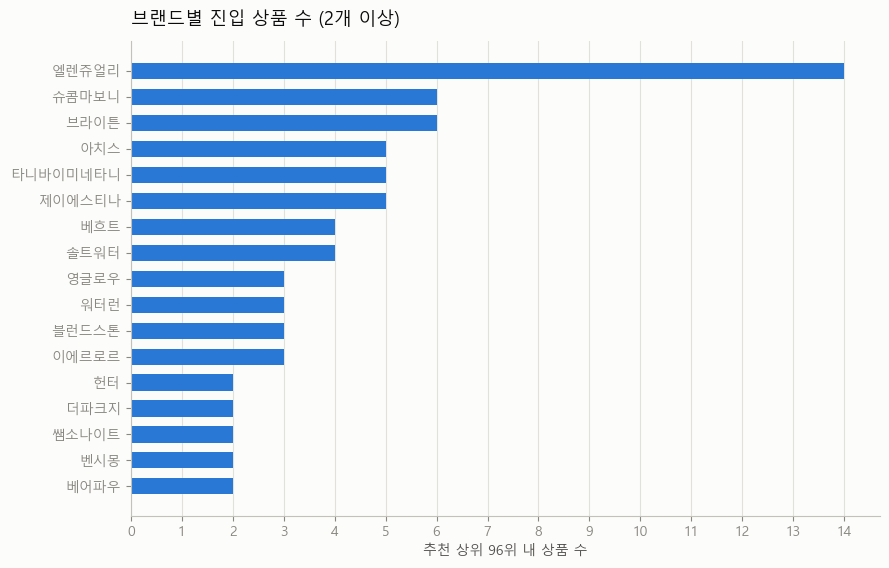

브랜드 미표기 상품: 0개 (0%)
1개 상품 브랜드: 25개


In [6]:
named = prod[prod['브랜드'] != '(미표기)']
brand_cnt = named['브랜드'].value_counts()
top = brand_cnt[brand_cnt >= 2].sort_values()

fig, ax = plt.subplots(figsize=(9, max(3.5, 0.34 * len(top))))
ax.barh(top.index, top.values, color=BLUE, height=0.62)
ax.set_xlabel(f'추천 상위 {len(prod)}위 내 상품 수')
ax.set_title('브랜드별 진입 상품 수 (2개 이상)', loc='left', fontsize=13, pad=12)
ax.set_xticks(range(0, int(top.max()) + 1))
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

print(f"브랜드 미표기 상품: {(prod['브랜드'] == '(미표기)').sum()}개 ({(prod['브랜드'] == '(미표기)').mean():.0%})")
print(f"1개 상품 브랜드: {(brand_cnt == 1).sum()}개")

**엘렌쥬얼리 14개 — 소수 브랜드 큐레이션 + 얕은 롱테일**

- 엘렌쥬얼리(14)·슈콤마보니(6)·브라이튼(6) 등 소수 브랜드가 상위 노출을 주도. 1개 상품 브랜드는 25개로 롱테일도 있지만, 노출 상단은 소수 브랜드가 반복 점유
- 미표기 0% — 상품명 `[브랜드]` 패턴 추출 완전 동작

#### 4. 리뷰수 집중도 — 판매가 얼마나 소수 상품에 쏠려 있나

컬리는 별점이 없어 리뷰수(누적 판매 프록시)의 분포로 상품 간 변별을 본다.
`999+`는 999로 치환된 값이라 실제 집중도는 이보다 **더 높다**(보수적 추정).

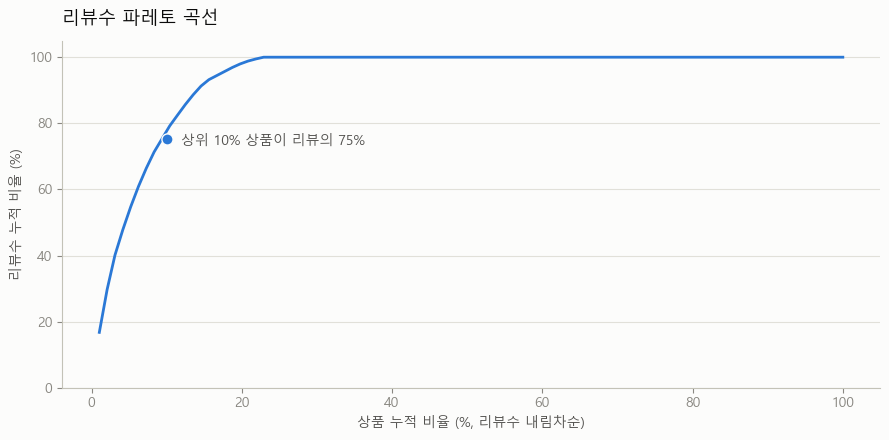

리뷰 0건 상품: 74개 / 96개
리뷰수 상한(999+) 도달 상품: 0개


In [7]:
s = prod['리뷰수'].sort_values(ascending=False).reset_index(drop=True)
share = s.cumsum() / s.sum() * 100
x = (s.index + 1) / len(s) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x, share, color=BLUE, linewidth=2)
p10 = share.iloc[max(0, int(len(s) * 0.1) - 1)]
ax.scatter([10], [p10], s=64, color=BLUE, zorder=3, edgecolor=SURFACE, linewidth=1)
ax.annotate(f'상위 10% 상품이 리뷰의 {p10:.0f}%', (10, p10),
            textcoords='offset points', xytext=(10, -4), fontsize=10, color=SECONDARY)
ax.set_xlabel('상품 누적 비율 (%, 리뷰수 내림차순)')
ax.set_ylabel('리뷰수 누적 비율 (%)')
ax.set_ylim(0, 105)
ax.set_title('리뷰수 파레토 곡선', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(f"리뷰 0건 상품: {(prod['리뷰수'] == 0).sum()}개 / {len(prod)}개")
print(f"리뷰수 상한(999+) 도달 상품: {prod['리뷰수상한'].sum()}개")

**상위 10% 상품이 리뷰의 75% — 극단적 수요 집중**

- 리뷰 0건 상품이 74/96(77%) — 수요가 극소수 검증 상품에 몰려 있다. 999+ 도달 상품 0개
- 고단가 잡화는 반복구매가 적어, 리뷰 있는 소수 상품에 판매가 집중되고 신규 진입 장벽이 높다

#### 5. 리뷰 텍스트 — 무엇에 만족하고 무엇을 걱정하나

별점이 없으므로 평점 그룹 비교 대신 **전체 리뷰의 빈출 키워드와 속성 언급률**을 본다.
(수집 리뷰는 추천순 상위라 긍정 편향이 있음을 감안하고 읽는다.)

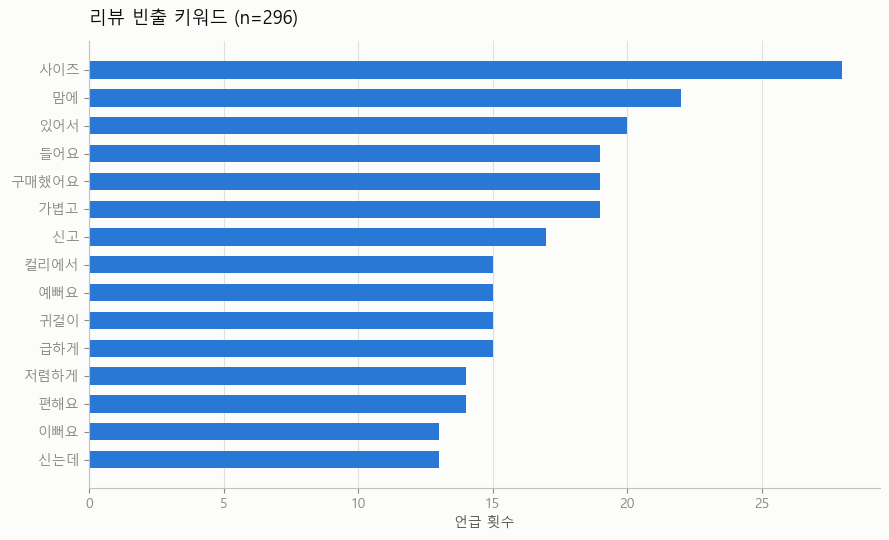

In [8]:
# 리뷰 미수집 상태면 이 장은 건너뛴다
if rev.empty:
    print('리뷰 파일이 없습니다 — 리뷰 수집 후 실행하세요.')
else:
    # 간단 토큰화(2글자 이상 한글) + 범용 표현 불용어 제거
    STOP = set('있어요 있습니다 같아요 그리고 너무 정말 진짜 그냥 조금 아주 많이 잘 더 좀 것 수 때 거 '
               '저는 제가 근데 하고 입니다 있는 없이 같은 살짝 완전 계속 다시 하나 해서 위에 이번 다른 '
               '이거 봐요 봐서 그래서 하는 한 번 안 못 딱 좋아요 좋습니다 좋아서 좋고 좋음 굿 최고 '
               '만족합니다 만족해요 않고 엄청 생각보다 좋네요 마음에 입기 입고 입을 입어도 구매 주문 '
               '컬리 샀는데 사서 사길 했어요 했는데 합니다 해요'.split())

    def tokens(text):
        return [t for t in re.findall(r'[가-힣]{2,}', str(text)) if t not in STOP]

    top15 = pd.Series(Counter(t for s in rev['Review Body'] for t in tokens(s))).nlargest(15)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.barh(top15.index[::-1], top15.values[::-1], color=BLUE, height=0.62)
    ax.set_xlabel('언급 횟수')
    ax.set_title(f'리뷰 빈출 키워드 (n={len(rev)})', loc='left', fontsize=13, pad=12)
    ax.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

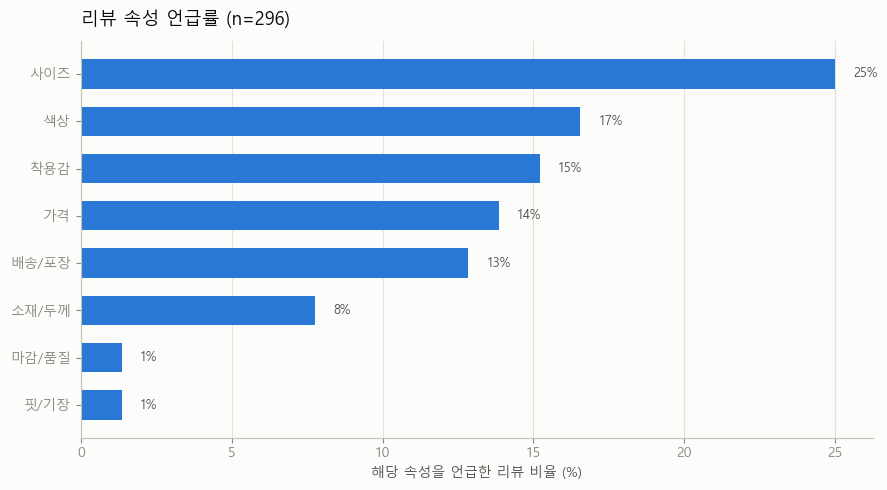

In [9]:
# 리뷰 미수집 상태면 이 장은 건너뛴다
if rev.empty:
    print('리뷰 파일이 없습니다 — 리뷰 수집 후 실행하세요.')
else:
    # 속성 사전 기반 언급률 — 패션 카테고리 공통 속성
    ASPECTS = {
        '사이즈': '사이즈|크기',
        '핏/기장': '핏|기장|어깨|허리|통이',
        '소재/두께': '소재|원단|재질|두께|얇|두껍',
        '색상': '색상|색감|컬러|색이',
        '착용감': '편하|편안|불편',
        '마감/품질': '마감|봉제|박음질|실밥|보풀|품질',
        '배송/포장': '배송|포장',
        '가격': '가격|가성비|세일|할인',
    }
    rates = pd.Series(
        {k: rev['Review Body'].str.contains(p).mean() * 100 for k, p in ASPECTS.items()}
    ).sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(rates.index, rates.values, color=BLUE, height=0.62)
    for i, v in enumerate(rates.values):
        ax.text(v + 0.6, i, f'{v:.0f}%', va='center', fontsize=9, color=SECONDARY)
    ax.set_xlabel('해당 속성을 언급한 리뷰 비율 (%)')
    ax.set_title(f'리뷰 속성 언급률 (n={len(rev)})', loc='left', fontsize=13, pad=12)
    ax.grid(True, axis='x')
    plt.tight_layout()
    plt.show()

    rates.sort_values(ascending=False).round(1)

**사이즈·색상·착용감이 잡화 구매의 핵심 정보**

- 속성 언급률: 사이즈 25% · 색상 17% · 착용감 15% · 가격 14% 순. 슈즈·주얼리 특성상 사이즈·색·착용감이 만족의 축
- 빈출 키워드도 '사이즈·맘에·가볍고·신고' 등 실착 경험 언어가 상위
- 별점이 없어 저평점 비교가 불가하므로, 후속으로 '불편·아쉽·별로' 등 부정 표현과 동시 등장하는 속성을 집계할 예정

#### 종합 인사이트

1. **가격/할인**: 중앙값 215,555원의 고단가 잡화. 정가 판매 29%·할인 중앙값 19%로 169(정가 4%·할인 45%)보다 완만한 할인 — 할인보다 정가 신뢰로 파는 카테고리
2. **브랜드**: 엘렌쥬얼리·슈콤마보니·브라이튼 등 소수 브랜드 큐레이션. 미표기 0%
3. **수요 집중도**: 상위 10% 상품이 리뷰의 75%, 리뷰 0건이 77% — 극소수 검증 상품 중심
4. **다음**: 리뷰 본문 수집 후 텍스트 분석(5장), 무신사·컬리 169와 채널 간 비교는 `app.py` 대시보드에서